In [7]:
# torch
import torch
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import v2 as T
from torchsummary import summary
import webbrowser
import subprocess
import matplotlib.pyplot as plt
import time

# paths
import os
import sys

# set paths
project_root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root_path)

# set random
import random

# my imports
from datasets.voc_subset import VOCSubset
from models.MoMi_detection import MoMiDetectionModel
from models.trainer_multi import TrainerMulti
from utils.plot_utils import plot_images_from_voc_dataset
from utils.voc_utils import custom_collate_fn

# The lifesaver
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Torch setup
torch.manual_seed(42)
random.seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [9]:
# TensorBoard open
timestamp = time.strftime("%b-%d_%H-%M-%S")
log_dir = os.path.join(project_root_path, "models", "model_logs", "p_03", f"{timestamp}")
tb_writer = SummaryWriter(log_dir)
print(f"TensorBoard logs are saved in: {log_dir}")

TensorBoard logs are saved in: /Users/fouadaz/LearningFromUniversity/Learning/IntroImageProcessing/Work_final_Project_nn/Project_DL_CV/models/model_logs/p_03/Mar-16_03-00-58


In [10]:
# Launch TensorBoard
port = 6008
tb = subprocess.Popen(
    ["tensorboard", f"--logdir={log_dir}", f"--port={port}", "--host=localhost"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
webbrowser.open(f"http://localhost:{port}");

## P3 - Single Class, Multiple Instance
In this part we will train a detector for single class, multiple instances per image.

### Model Construction
We begin by loading the single object multiple instance (somi) detection model, with the MobilNet V3 Backbone.

In [11]:
# Build MoMi Model (single-class, multi-instance) and send to device
model = MoMiDetectionModel(num_classes=2).to(device)

# OPTIONAL: If you want to ensure all buffers are on MPS too:
for name, buf in model.named_buffers():
    if buf.device != device:
        buf.data = buf.data.to(device)
        print(f"Moved buffer '{name}' to {device}")

# Print summary
summary(model, input_size=(3, 224, 224), device=str(device))

# Workaround for add_graph on MPS: Use CPU copy
if device.type == "mps":
    import copy
    model_cpu = copy.deepcopy(model).cpu()
    sim_image_cpu = torch.randint(low=0, high=256, size=(1, 3, 224, 224), dtype=torch.float32)
    tb_writer.add_graph(model_cpu, sim_image_cpu)
else:
    sim_image = torch.randint(low=0, high=256, size=(1, 3, 224, 224), dtype=torch.float32).to(device)
    tb_writer.add_graph(model, sim_image)

Moved buffer 'backbone.0.1.running_mean' to mps
Moved buffer 'backbone.0.1.running_var' to mps
Moved buffer 'backbone.0.1.num_batches_tracked' to mps
Moved buffer 'backbone.1.block.0.1.running_mean' to mps
Moved buffer 'backbone.1.block.0.1.running_var' to mps
Moved buffer 'backbone.1.block.0.1.num_batches_tracked' to mps
Moved buffer 'backbone.1.block.1.1.running_mean' to mps
Moved buffer 'backbone.1.block.1.1.running_var' to mps
Moved buffer 'backbone.1.block.1.1.num_batches_tracked' to mps
Moved buffer 'backbone.2.block.0.1.running_mean' to mps
Moved buffer 'backbone.2.block.0.1.running_var' to mps
Moved buffer 'backbone.2.block.0.1.num_batches_tracked' to mps
Moved buffer 'backbone.2.block.1.1.running_mean' to mps
Moved buffer 'backbone.2.block.1.1.running_var' to mps
Moved buffer 'backbone.2.block.1.1.num_batches_tracked' to mps
Moved buffer 'backbone.2.block.2.1.running_mean' to mps
Moved buffer 'backbone.2.block.2.1.running_var' to mps
Moved buffer 'backbone.2.block.2.1.num_batc

### Dataset
Next, we load the `subset` dataset with the single class `cat` and split for train and validation. Since we have only ~1000 images we won't split into 3 (test).

In [12]:
# Define the selected class
selected_class_name = "cat"

# Load the file containing the indices of images with the selected class
indices_file = os.path.join("..", "datasets", f"voc_{selected_class_name}_selected_indices.pth")
indices_file_2 = os.path.join("..", "datasets", f"voc_{selected_class_name}_multiple_indices.pth")

class_idx = torch.load(indices_file)
multiple_class_idx = torch.load(indices_file_2)

##### Dataset augmentation and train-val split
We have ~1084 instances of the selected class `cat`. To better train the model, we would augment them with additional `k` times the dataset length of random images that are not from this class, to add some negative examples.

The total set of images `aug_idx` will be randomly split to train and valid.

In [13]:
# ratio mix
k, k_1, k_2 = 0, 0, 1

available_idx = set(range(11540)) - set(class_idx)

aug_idx = (
    random.sample(available_idx, min(k * len(class_idx), len(available_idx)))
    + k_1 * class_idx
    + k_2 * multiple_class_idx
)

print(
    f"Total of {len(aug_idx)} samples, "
    f"of which {len(class_idx)} contain the selected class '{selected_class_name}'."
)

# split the indices to a train-valid ratio
split_ratio = 0.8
random.shuffle(aug_idx)
train_size = int(split_ratio * len(aug_idx))
train_idx = aug_idx[:train_size]
val_idx = aug_idx[train_size:]

print(f"Train indices of length {len(train_idx)} and val indices of length {len(val_idx)}.")

Total of 118 samples, of which 1084 contain the selected class 'cat'.
Train indices of length 94 and val indices of length 24.


/var/folders/78/hsq9362565qck24p_twrvs0cx236x4/T/ipykernel_99715/2379027695.py:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  random.sample(available_idx, min(k * len(class_idx), len(available_idx)))


#### Transforms
Before bulding the dataset we need to define transformations on the data using `get_trainsform`. 

This function has two modes: train = `True` for training and `False` for validation and inference. In train mode, we will add additional agumentations to enhance the training robustness. 

In inference \ validation, only the basic data transformations from the model backbone defaults are executed.

In [14]:
def get_transform(train, backbone_transforms):
    transforms = []
    
    # standard transforms - resizing & center cropping
    transforms.append(
        T.Resize(
            size=backbone_transforms.resize_size,
            interpolation=backbone_transforms.interpolation
        )
    )
    transforms.append(T.CenterCrop(size=backbone_transforms.crop_size))
    
    # if training, add flips & jitters
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
        transforms.append(T.RandomVerticalFlip(0.5))
        transforms.append(T.RandomRotation(10))
        transforms.append(T.ColorJitter(brightness=0.2, contrast=0.2,
                                        saturation=0.2, hue=0.2))
    
    # standard normalizing
    transforms.append(T.ToImage())
    transforms.append(T.ToDtype(torch.float32, scale=True))  # scale to 0-1
    transforms.append(
        T.Normalize(
            mean=backbone_transforms.mean,
            std=backbone_transforms.std
        )
    )
    return T.Compose(transforms)

### Datasets
Build two datasets, each with the appropriate transformations and indices. 

In [15]:
# training dataset
train_dataset = VOCSubset(
    indices_list=train_idx,
    selected_class=selected_class_name,
    single_instance=False,  # multiple instances
    transforms=get_transform(train=True, backbone_transforms=model.backbone_transforms()),
    download=False
)

# validation dataset
val_dataset = VOCSubset(
    indices_list=val_idx,
    selected_class=selected_class_name,
    single_instance=False,
    transforms=get_transform(train=False, backbone_transforms=model.backbone_transforms()),
    download=False
)

print(
    f"Train dataset of length {len(train_dataset)} and "
    f"Val dataset of length {len(val_dataset)}."
)

Train dataset of length 94 and Val dataset of length 24.


#### Test Dataset
We would like to see that the dataset includes these samples and bounding boxes.

/Users/fouadaz/LearningFromUniversity/tools/anaconda3/envs/custom_CatSemSeg/lib/python3.9/site-packages/torchvision/utils.py:223: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


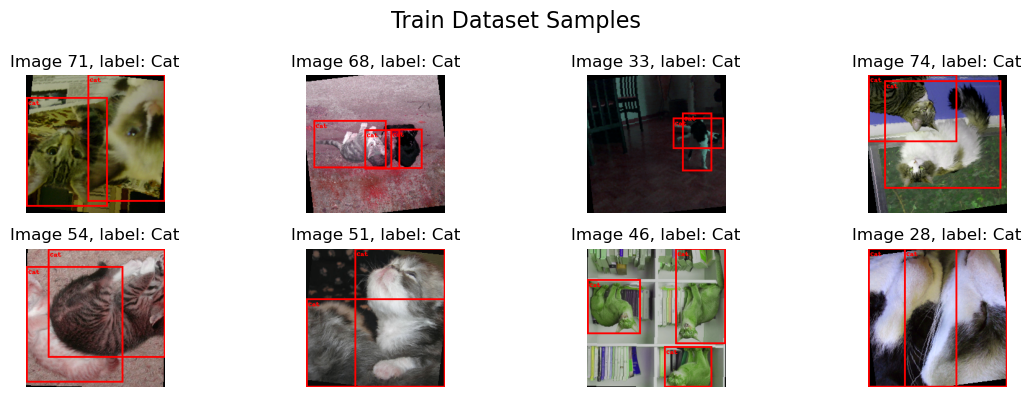

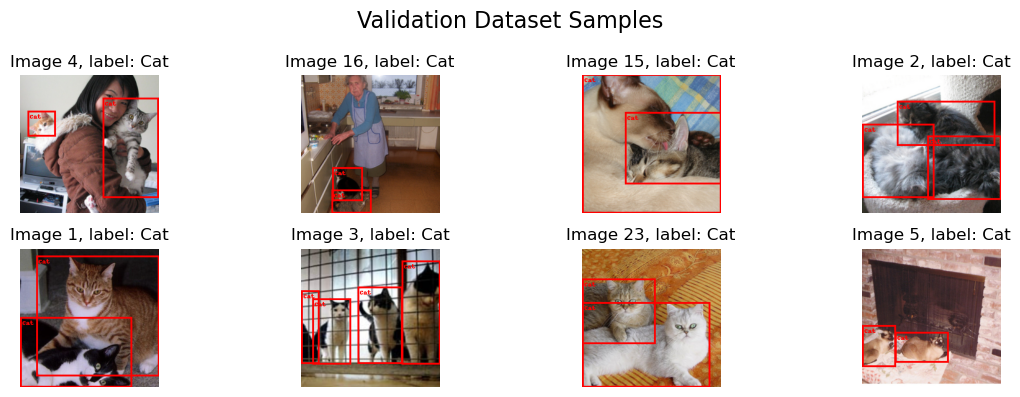

In [16]:
# Quick sanity check: plot some dataset samples
plot_images_from_voc_dataset(train_dataset, num_images=8, title="Train Dataset Samples")
plot_images_from_voc_dataset(val_dataset, num_images=8, title="Validation Dataset Samples")

#### Build data loaders:

In [17]:
# DataLoaders with custom collate
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    pin_memory=True,
    drop_last=False,
    collate_fn=custom_collate_fn
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    pin_memory=True,
    drop_last=False,
    collate_fn=custom_collate_fn
)

### Training Preparation

First, we specify the learning hyperparameters.

In [18]:
# Hyperparameters
lr = 1e-3
lr_scheduler_step = 10
lr_gamma = 0.75

##### Construct Optimizer and Scheduler 

In [19]:
# Create optimizer / scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, lr_scheduler_step, lr_gamma)

##### Construct loss functions
We will use `CrossEntropyLoss` for the classes (with from_logits = `True` as we do not apply softmax in the model), and `MSE` for the bounding box point loss.

In [20]:
# Create optimizer / scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, lr_scheduler_step, lr_gamma)

# Losses: bounding box, classification, objectness
boxes_loss_f = torch.nn.MSELoss()
class_loss_f = torch.nn.CrossEntropyLoss()
obj_loss_f = torch.nn.BCEWithLogitsLoss()

losses = [boxes_loss_f, class_loss_f, obj_loss_f]
tb_writer.add_text("Experiment", "Single-class multiple-instance detection.")

In [21]:
# (Optional) Quick test with one sample
sample_img, sample_boxes, sample_labels = train_dataset[0]
print("Sample image shape:", sample_img.shape, "Boxes:", sample_boxes, "Labels:", sample_labels)

sample_img = sample_img.unsqueeze(0).to(device)
with torch.no_grad():
    pred_boxes, pred_class_logits, pred_obj_logits = model(sample_img)
    print("Pred boxes shape:", pred_boxes.shape)         # e.g. [1, 49, 4]
    print("Pred class logits shape:", pred_class_logits.shape)  # e.g. [1, 49, num_classes]
    print("Pred obj logits shape:", pred_obj_logits.shape)      # e.g. [1, 49, 1]

Sample image shape: torch.Size([3, 224, 224]) Boxes: BoundingBoxes([[0.0000, 0.0000, 0.9037, 0.7044],
               [0.3514, 0.1703, 0.6486, 0.7015]], format=BoundingBoxFormat.XYWH, canvas_size=tensor([224, 224])) Labels: tensor([1., 1.], dtype=torch.float16)
Pred boxes shape: torch.Size([1, 49, 4])
Pred class logits shape: torch.Size([1, 49, 2])
Pred obj logits shape: torch.Size([1, 49, 1])


In [22]:
a,b,c = train_dataset[0]
a = a.to(device).unsqueeze(0)

In [23]:
c

tensor([1., 1.], dtype=torch.float16)

In [24]:
model.inference(a)

(tensor([[[0.4061, 0.4782, 0.4644, 0.5966]]], device='mps:0',
        grad_fn=<StackBackward0>),
 tensor([[1]], device='mps:0'),
 tensor([[0.5604]], device='mps:0', grad_fn=<StackBackward0>))

### Training loop

In [25]:
tb_writer.add_text("Comment", "Testing linear layers in the model")

In [26]:
# Instantiate the Trainer
trainer = TrainerMulti(
    device=device,
    model=model,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    losses=losses,
    writer=tb_writer,
    lr_scheduler=lr_scheduler
)

In [27]:
# Train
final_img_grid = trainer.train(
    max_epochs=10,
    log_images_every=1
)

Validation Epoch 10: 100%|██████████| 24/24 [00:00<00:00, 46.83it/s]


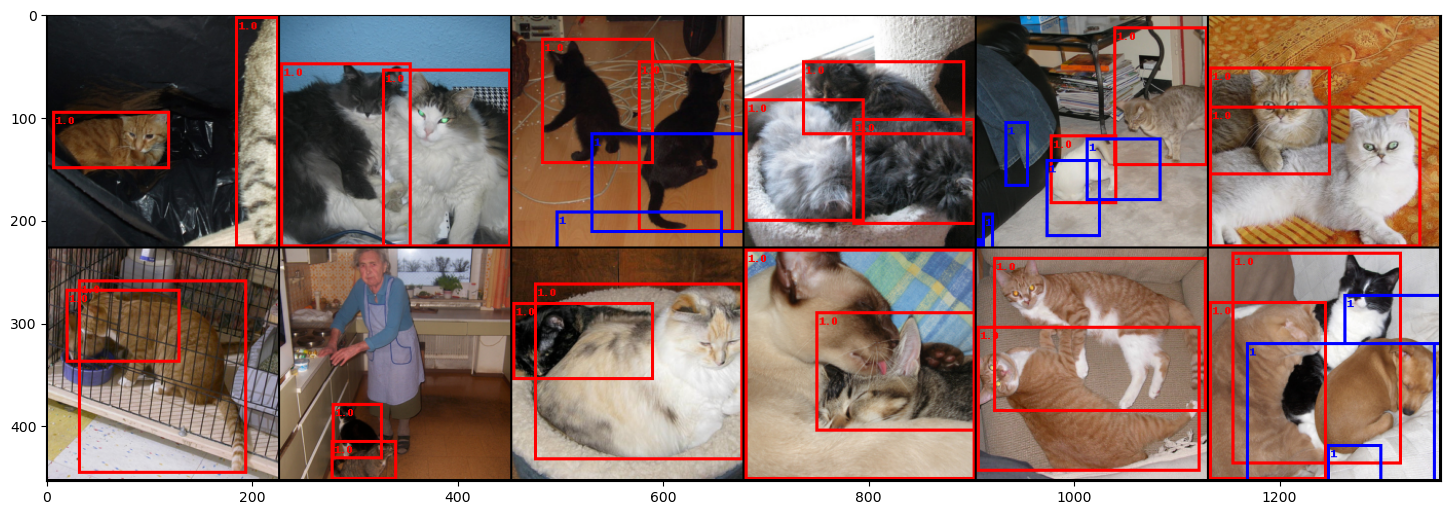

In [28]:
_, ax = plt.subplots(figsize=(18, 9))
ax.imshow(final_img_grid.permute(1, 2, 0));

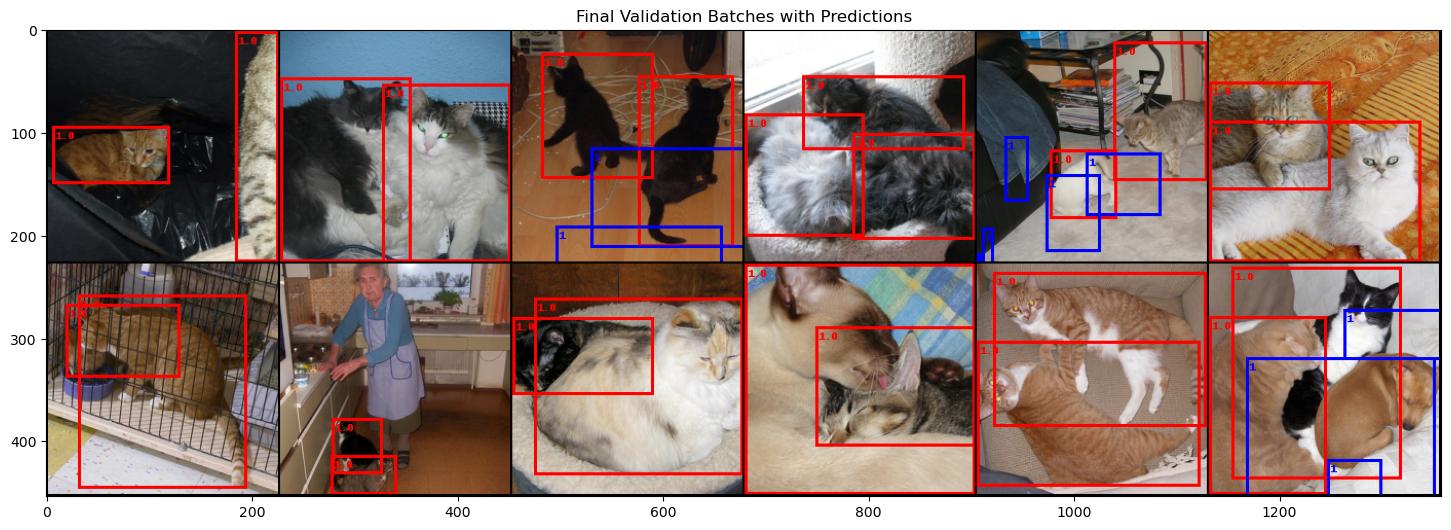

In [29]:
# Display final image grid if it exists
if final_img_grid is not None:
    _, ax = plt.subplots(figsize=(18, 9))
    ax.imshow(final_img_grid.permute(1, 2, 0))
    ax.set_title("Final Validation Batches with Predictions")
    plt.show()
else:
    print("No final image grid returned (e.g. if no validation logging).")

Clean up and save

In [30]:
# tb.terminate()
torch.save(model.state_dict(), f"p2_model_{timestamp}.pth")  